In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


# HOUSE

In [19]:
X_train,X_test,y_train,y_test=load("housing_features.csv")

NameError: name 'load' is not defined

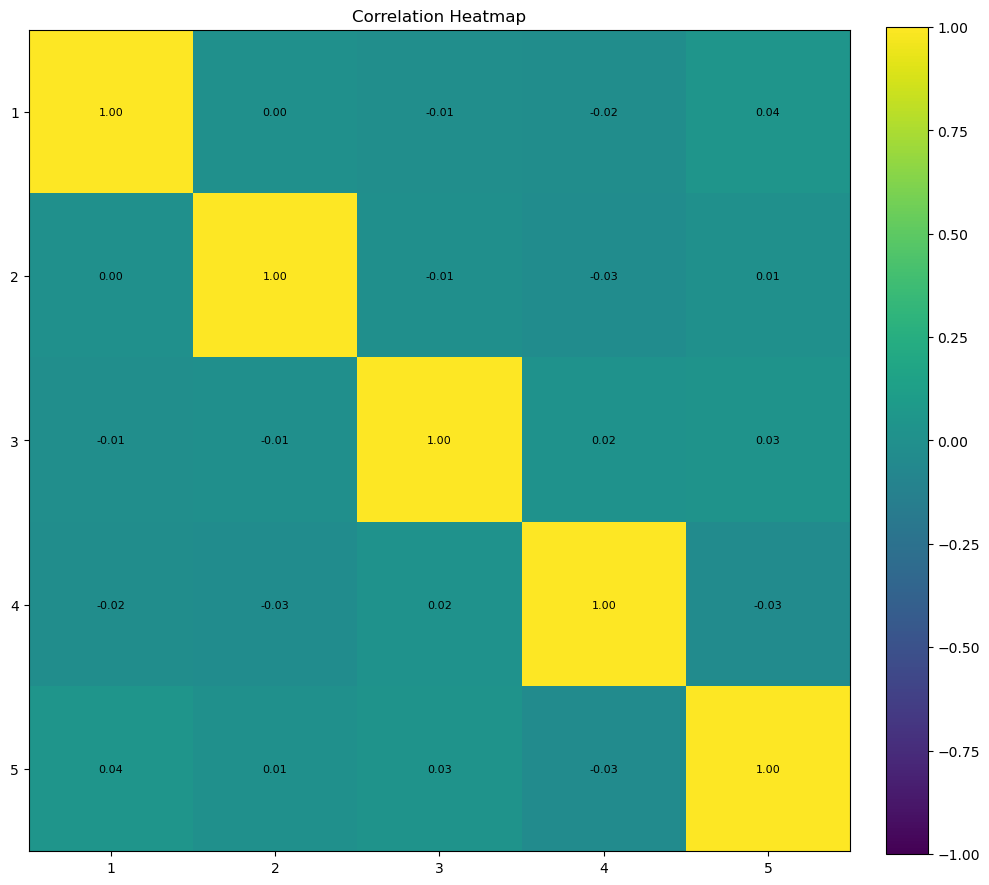

In [20]:
corr = np.corrcoef(X_train, rowvar=False)

n = corr.shape[0]
labels = np.arange(1, n + 1)

plt.figure(figsize=(10, 10))
im = plt.imshow(corr, vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(n), labels)
plt.yticks(np.arange(n), labels)

# annotate values
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{corr[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

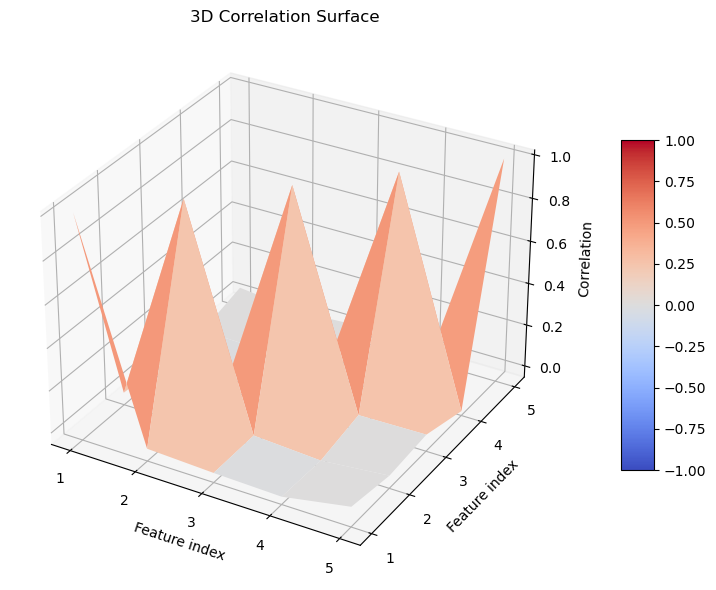

In [21]:
corr = np.corrcoef(X_train, rowvar=False)

n = corr.shape[0]
x = np.arange(1, n + 1)
y = np.arange(1, n + 1)
Xg, Yg = np.meshgrid(x, y)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection="3d")


surf = ax.plot_surface(
    Xg, Yg, corr,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("Feature index")
ax.set_ylabel("Feature index")
ax.set_zlabel("Correlation")

ax.set_xticks(x)
ax.set_yticks(y)

ax.view_init(elev=30)

fig.colorbar(surf, shrink=0.6, aspect=10, pad=0.08)

plt.title("3D Correlation Surface")
plt.tight_layout()
plt.show()


[ 19.97568288 -14.95574444   1.99677274  -9.95427944   9.97418631]
5


/tmp/ipykernel_263760/184955783.py:3: RuntimeWarning: divide by zero encountered in log
  log_al=np.log(np.array(alphas))


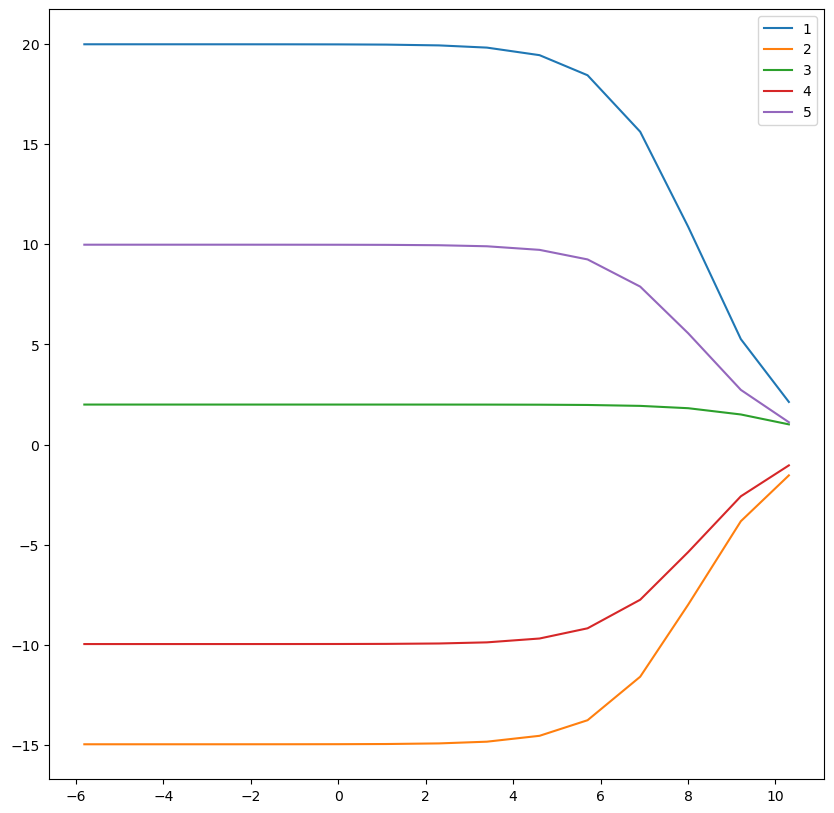

/home/aradhana/.local/lib/python3.10/site-packages/sklearn/base.py:1473: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  return fit_method(estimator, *args, **kwargs)
/home/aradhana/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
/home/aradhana/.local/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.785e+03, tolerance: 3.043e+02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model 

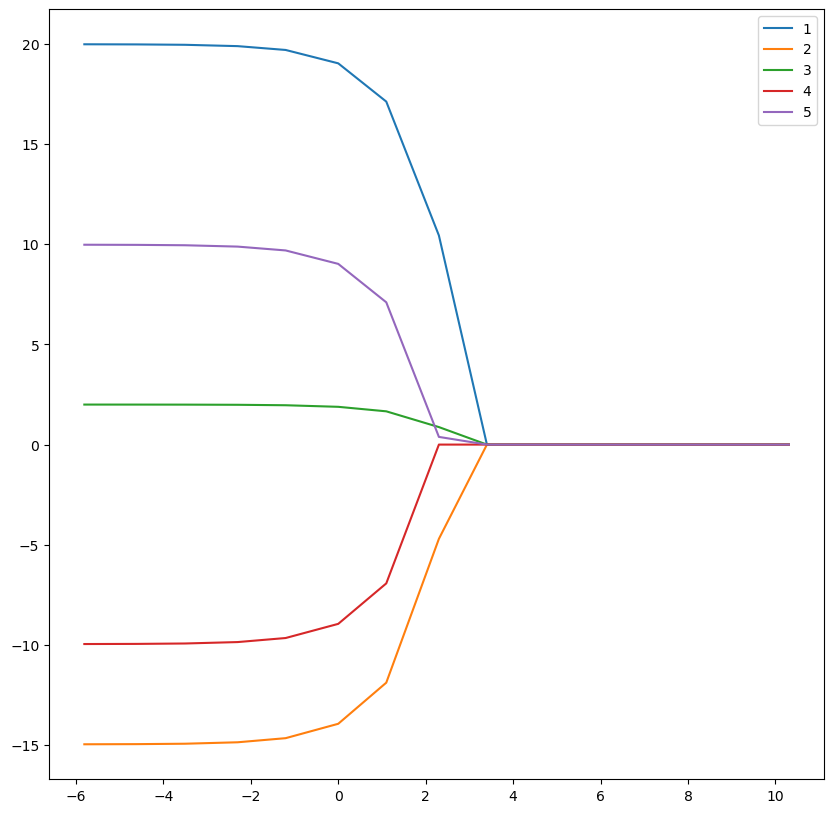

In [22]:
from sklearn import linear_model
alphas=[0,0.003,0.01,0.03,0.1,0.3,1,3,10,30,100,300,1000,3000,10000,30000]
log_al=np.log(np.array(alphas))
reg=linear_model.LinearRegression()
reg.fit(X_train,y_train)
y_pred_ols=reg.predict(X_test)
print(reg.coef_)

features=reg.coef_.size
print(features)
coeffs=[]
y_pred_ridge=[]
for i in alphas:
    ridge=linear_model.Ridge(alpha=i)
    ridge.fit(X_train,y_train)
    y_pred_ridge.append(ridge.predict(X_test))
    coeffs.append(ridge.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
# plt.xlim(0, 25)
plt.legend()
plt.show()

coeffs=[]
y_pred_lasso=[]
for i in alphas:
    lasso=linear_model.Lasso(alpha=i)
    lasso.fit(X_train,y_train)
    y_pred_lasso.append(lasso.predict(X_test))
    coeffs.append(lasso.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
# plt.xlim(0, 0.2)
plt.legend()
plt.show()


mean squared error: 0.9420641907184221 
r2 score: 0.9989301711487301 
coefficients (beta): [ 19.97568288 -14.95574444   1.99677274  -9.95427944   9.97418631] 



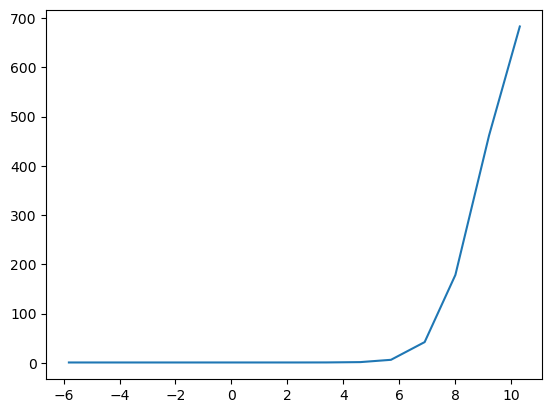

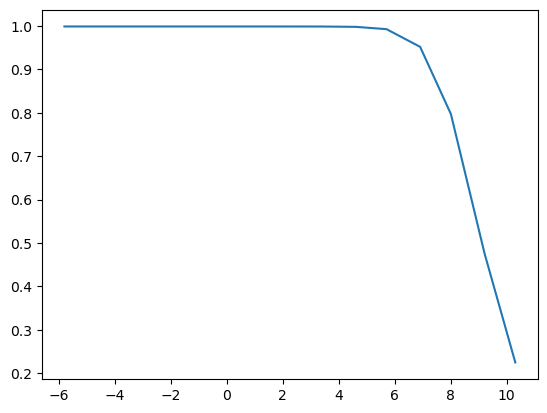

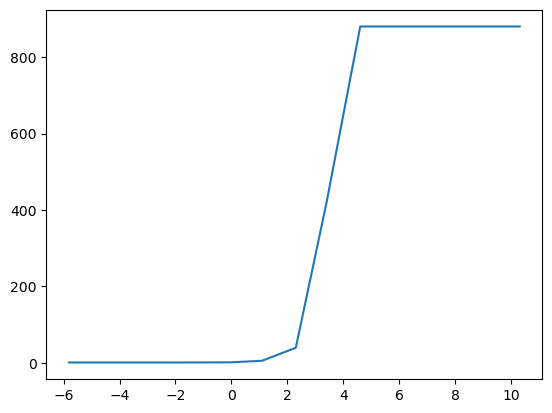

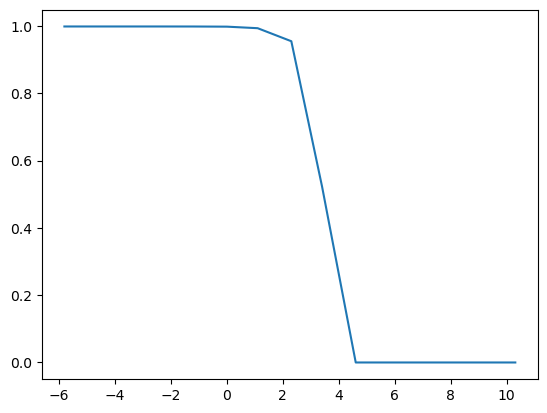

In [23]:
from sklearn import metrics
mse_ols=metrics.mean_squared_error(y_test,y_pred_ols)
r2_ols=metrics.r2_score(y_test,y_pred_ols)
print("mean squared error:",mse_ols,"\nr2 score:",r2_ols,"\ncoefficients (beta):",reg.coef_,"\n")

mse_ridge=[]
r2_ridge=[]
n=len(alphas)
for y_pred_row in y_pred_ridge[:n]:
    mse_ridge.append(metrics.mean_squared_error(y_test,y_pred_row))
    r2_ridge.append(metrics.r2_score(y_test,y_pred_row))
plt.figure()
plt.plot(log_al[:n],mse_ridge)
plt.figure()
plt.plot(log_al[:n],r2_ridge)

mse_lasso=[mse_ols]
r2_lasso=[r2_ols]
for y_pred_row in y_pred_lasso[:n-1]:
    mse_lasso.append(metrics.mean_squared_error(y_test,y_pred_row))
    r2_lasso.append(metrics.r2_score(y_test,y_pred_row))
plt.figure()
plt.plot(log_al[:n],mse_lasso)
plt.figure()
plt.plot(log_al[:n],r2_lasso)


# GENE


In [24]:
X_train,X_test,y_train,y_test=load("gene_features.csv")

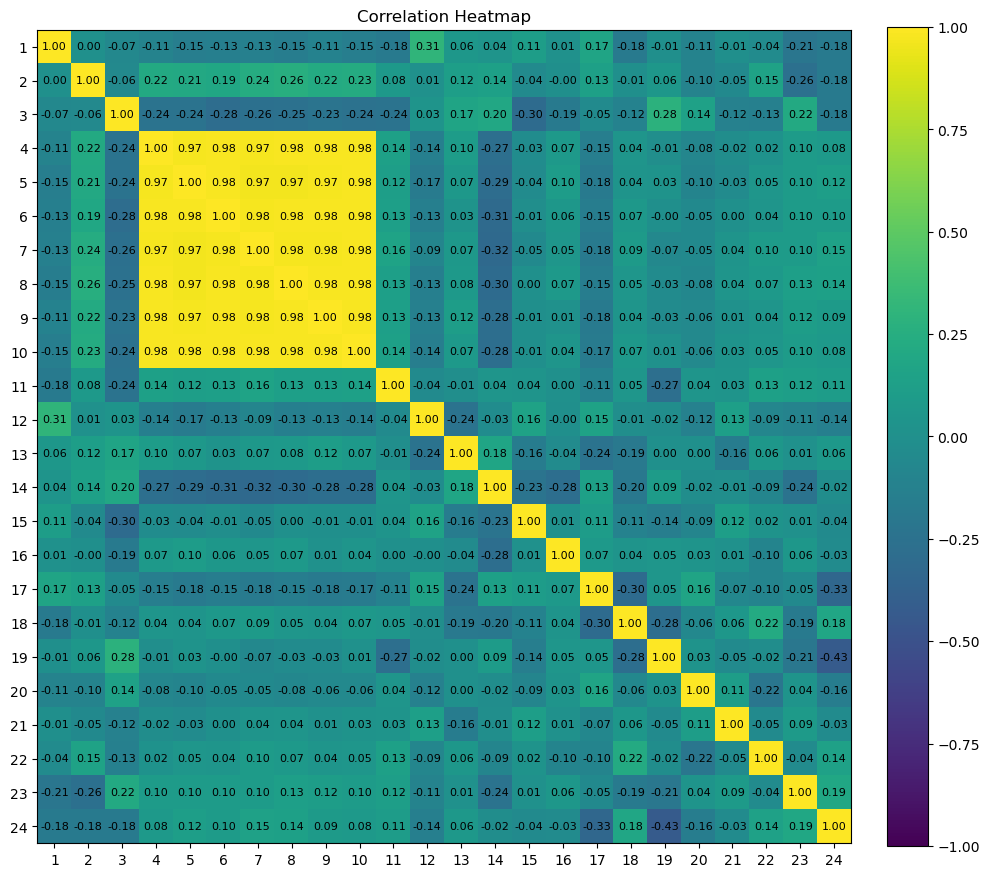

In [25]:
corr = np.corrcoef(X_train, rowvar=False)

n = corr.shape[0]
labels = np.arange(1, n + 1)

plt.figure(figsize=(10, 10))
im = plt.imshow(corr, vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(n), labels)
plt.yticks(np.arange(n), labels)

# annotate values
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{corr[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

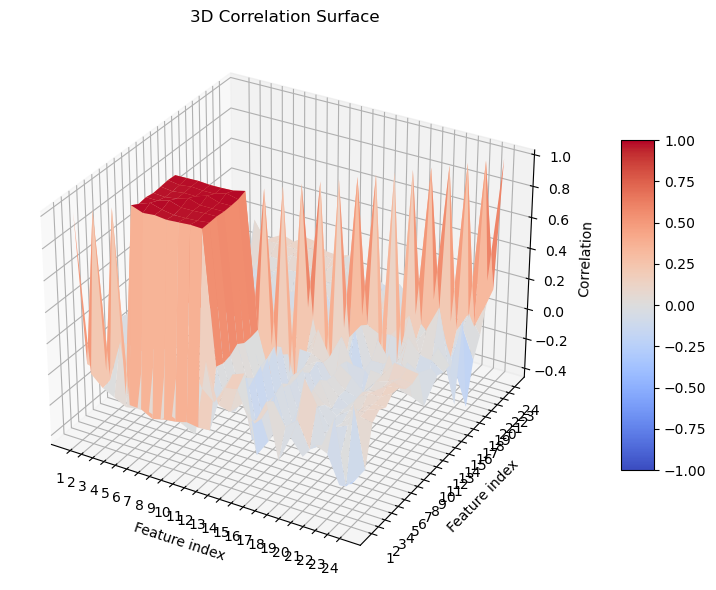

In [26]:
corr = np.corrcoef(X_train, rowvar=False)

n = corr.shape[0]
x = np.arange(1, n + 1)
y = np.arange(1, n + 1)
Xg, Yg = np.meshgrid(x, y)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection="3d")


surf = ax.plot_surface(
    Xg, Yg, corr,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("Feature index")
ax.set_ylabel("Feature index")
ax.set_zlabel("Correlation")

ax.set_xticks(x)
ax.set_yticks(y)

ax.view_init(elev=30)

fig.colorbar(surf, shrink=0.6, aspect=10, pad=0.08)

plt.title("3D Correlation Surface")
plt.tight_layout()
plt.show()


[ 2.06309066e+01 -1.45211622e+01  1.00830478e+01 -1.26303133e+00
  9.11397325e-01  4.22614767e+00 -1.11178024e+00  2.17853479e+00
 -6.61615313e+00  1.78007982e+00  3.20795246e-01  4.18288742e-02
  3.85193619e-01  3.57839456e-03  1.18220530e-01 -6.01769334e-01
 -7.95956719e-01  2.96880642e-01 -1.13663304e+00  5.52415000e-02
  2.89075751e-01 -5.07985606e-01  2.61997668e-01 -9.12866995e-01]
24


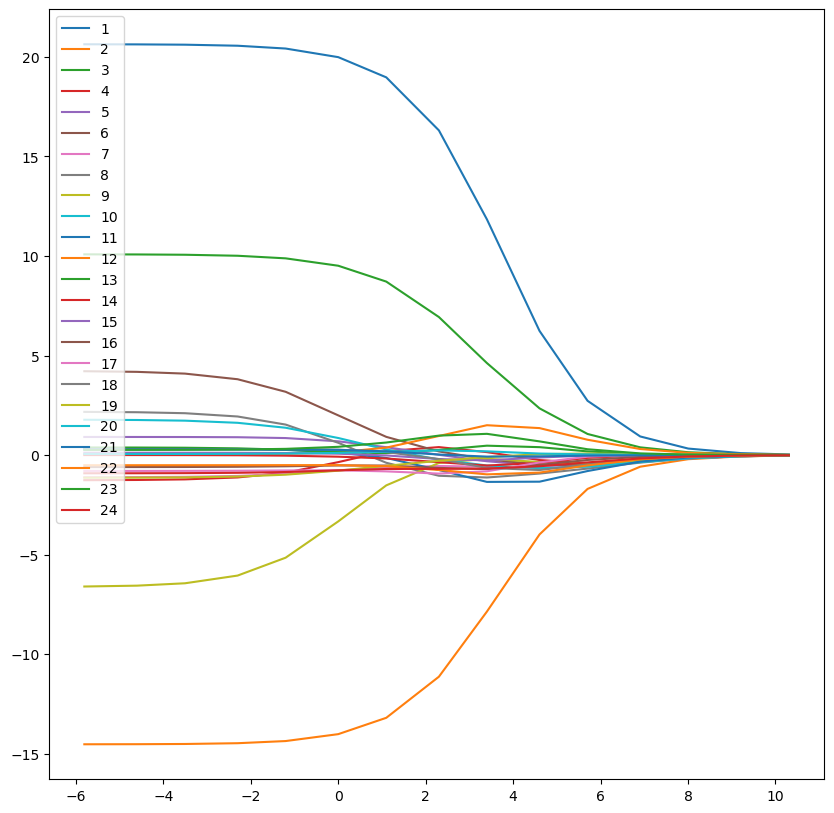

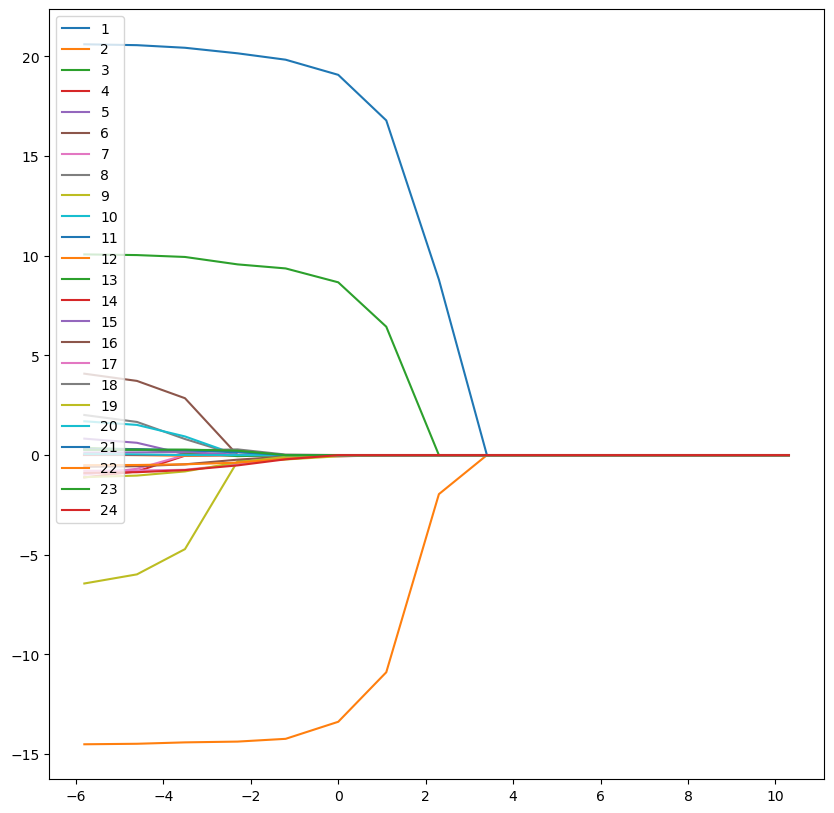

In [27]:
from sklearn import linear_model
alphas=[0,0.003,0.01,0.03,0.1,0.3,1,3,10,30,100,300,1000,3000,10000,30000]
reg=linear_model.LinearRegression()
reg.fit(X_train,y_train)
y_pred_ols=reg.predict(X_test)
print(reg.coef_)

features=reg.coef_.size
print(features)
coeffs=[]
y_pred_ridge=[]
for i in alphas:
    ridge=linear_model.Ridge(alpha=i)
    ridge.fit(X_train,y_train)
    y_pred_ridge.append(ridge.predict(X_test))
    coeffs.append(ridge.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.legend()
plt.show()

coeffs=[]
y_pred_lasso=[]
for i in alphas[1:]:
    lasso=linear_model.Lasso(alpha=i)
    lasso.fit(X_train,y_train)
    y_pred_lasso.append(lasso.predict(X_test))
    coeffs.append(lasso.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al[1:],coeffs[:,i],label=i+1)
plt.legend()
plt.show()


mean squared error: 16.322060259318363 
r2 score: 0.9758779404319612 
coefficients (beta): [ 2.06309066e+01 -1.45211622e+01  1.00830478e+01 -1.26303133e+00
  9.11397325e-01  4.22614767e+00 -1.11178024e+00  2.17853479e+00
 -6.61615313e+00  1.78007982e+00  3.20795246e-01  4.18288742e-02
  3.85193619e-01  3.57839456e-03  1.18220530e-01 -6.01769334e-01
 -7.95956719e-01  2.96880642e-01 -1.13663304e+00  5.52415000e-02
  2.89075751e-01 -5.07985606e-01  2.61997668e-01 -9.12866995e-01] 



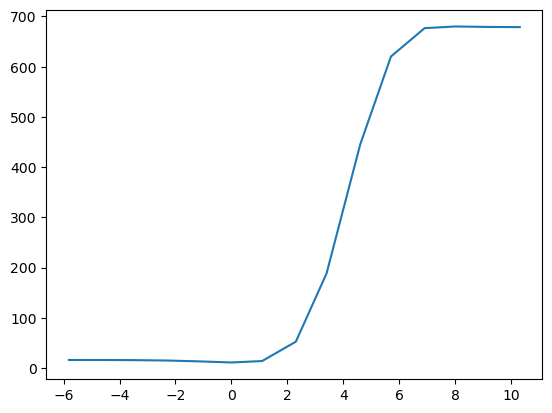

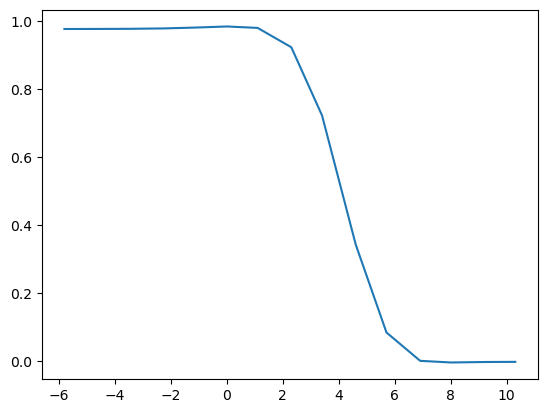

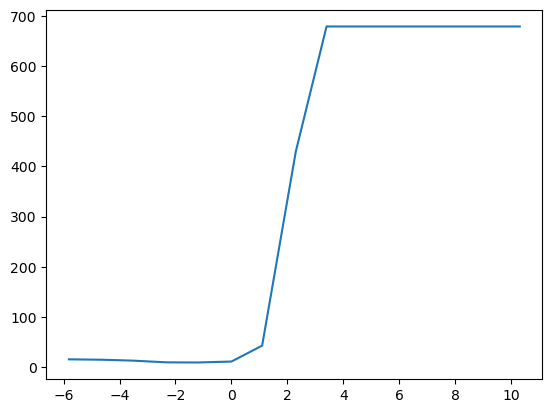

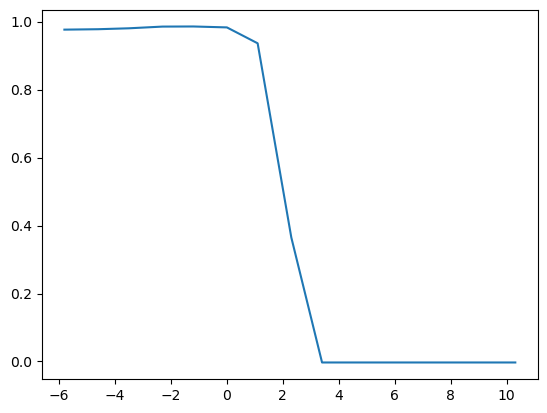

In [28]:
from sklearn import metrics
mse_ols=metrics.mean_squared_error(y_test,y_pred_ols)
r2_ols=metrics.r2_score(y_test,y_pred_ols)
print("mean squared error:",mse_ols,"\nr2 score:",r2_ols,"\ncoefficients (beta):",reg.coef_,"\n")

mse_ridge=[]
r2_ridge=[]
n=len(alphas)
for y_pred_row in y_pred_ridge[:n]:
    mse_ridge.append(metrics.mean_squared_error(y_test,y_pred_row))
    r2_ridge.append(metrics.r2_score(y_test,y_pred_row))
plt.figure()
plt.plot(log_al[:n],mse_ridge)
plt.figure()
plt.plot(log_al[:n],r2_ridge)

mse_lasso=[mse_ols]
r2_lasso=[r2_ols]
for y_pred_row in y_pred_lasso[:n-1]:
    mse_lasso.append(metrics.mean_squared_error(y_test,y_pred_row))
    r2_lasso.append(metrics.r2_score(y_test,y_pred_row))
plt.figure()
plt.plot(log_al[:n],mse_lasso)
plt.figure()
plt.plot(log_al[:n],r2_lasso)


# SENSOR

In [29]:
X_train,X_test,y_train,y_test=load("sensor_features.csv")

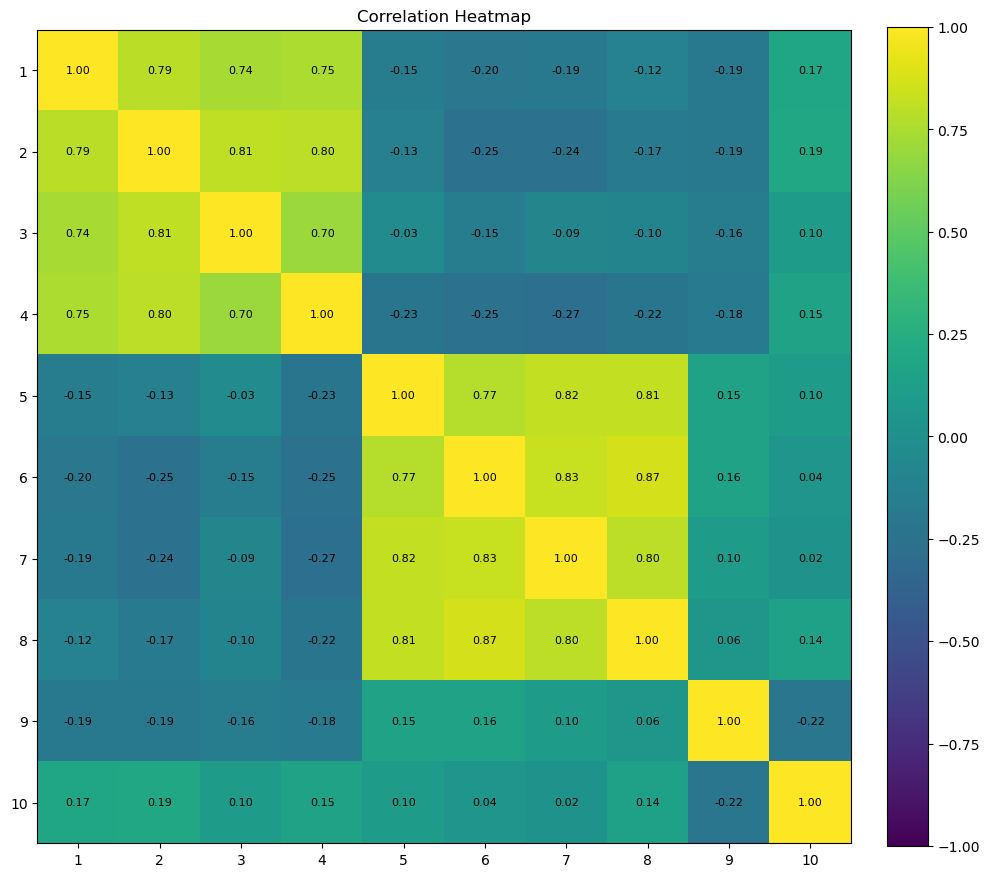

In [30]:
corr = np.corrcoef(X_train, rowvar=False)

n = corr.shape[0]
labels = np.arange(1, n + 1)

plt.figure(figsize=(10, 10))
im = plt.imshow(corr, vmin=-1, vmax=1)

plt.colorbar(im, fraction=0.046, pad=0.04)
plt.xticks(np.arange(n), labels)
plt.yticks(np.arange(n), labels)

# annotate values
for i in range(n):
    for j in range(n):
        plt.text(j, i, f"{corr[i, j]:.2f}",
                 ha="center", va="center", fontsize=8)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

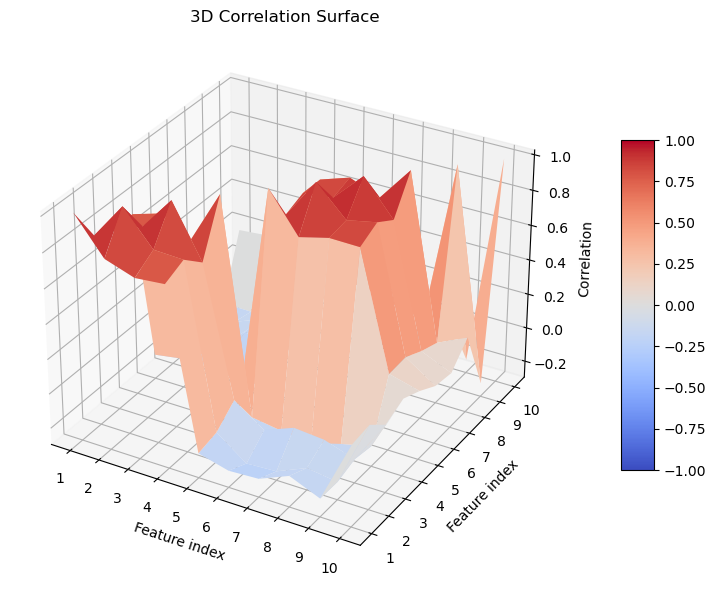

In [31]:
corr = np.corrcoef(X_train, rowvar=False)

n = corr.shape[0]
x = np.arange(1, n + 1)
y = np.arange(1, n + 1)
Xg, Yg = np.meshgrid(x, y)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection="3d")


surf = ax.plot_surface(
    Xg, Yg, corr,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidth=0,
    antialiased=True
)

ax.set_xlabel("Feature index")
ax.set_ylabel("Feature index")
ax.set_zlabel("Correlation")

ax.set_xticks(x)
ax.set_yticks(y)

ax.view_init(elev=30)

fig.colorbar(surf, shrink=0.6, aspect=10, pad=0.08)

plt.title("3D Correlation Surface")
plt.tight_layout()
plt.show()


[ 3.29941187  1.95248032  1.63032302  3.21826464  1.57950492  2.62964438
  4.07149154  1.09365998 -0.16926757  0.45127006]
10


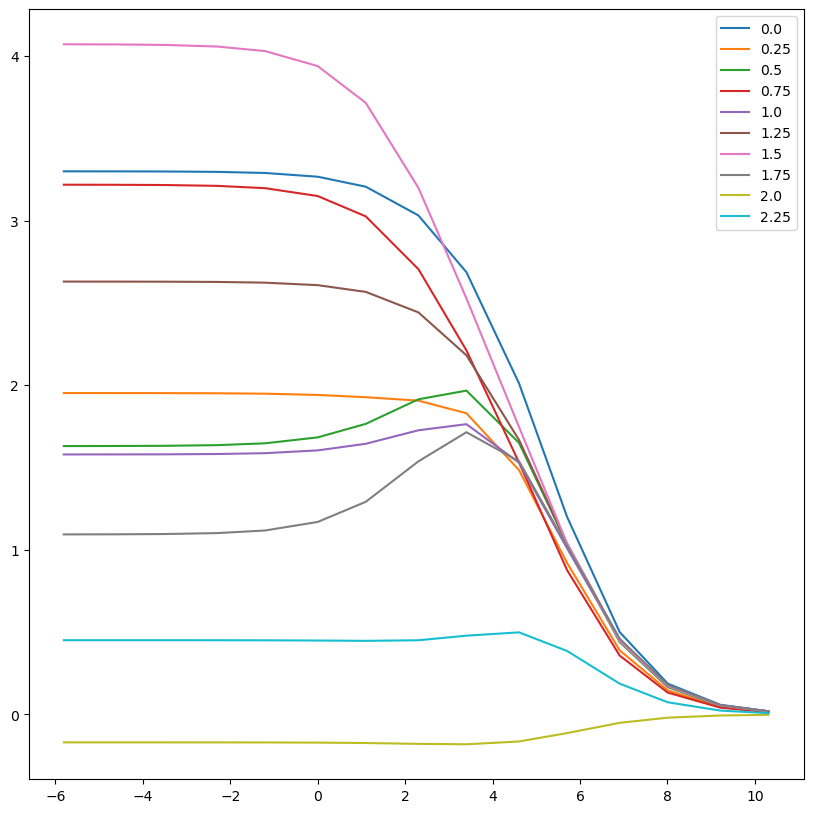

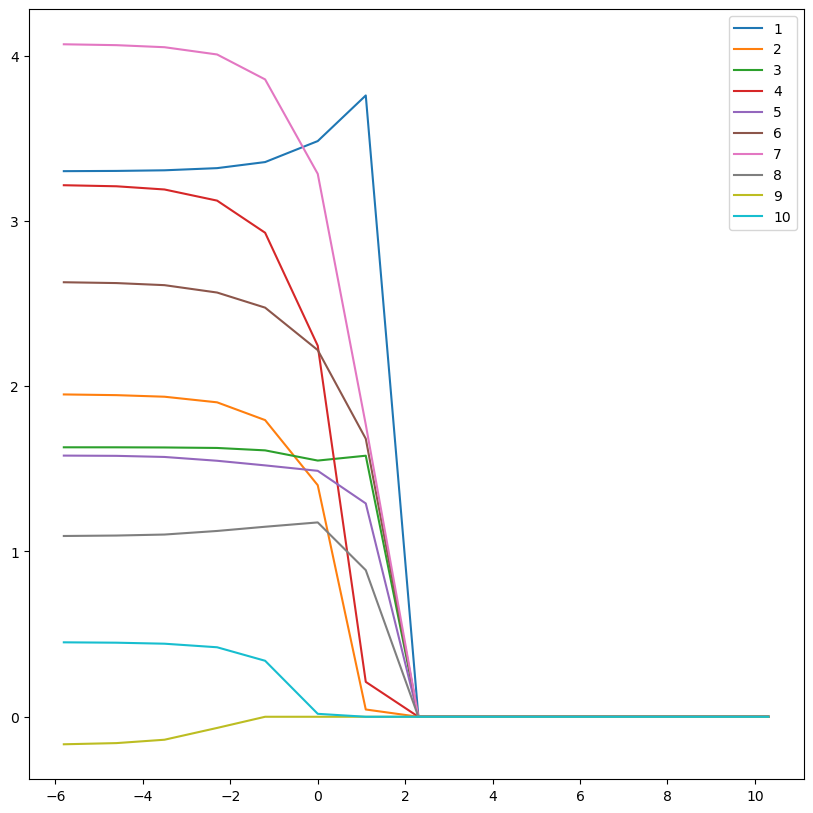

In [32]:
from sklearn import linear_model
alphas=[0,0.003,0.01,0.03,0.1,0.3,1,3,10,30,100,300,1000,3000,10000,30000]
reg=linear_model.LinearRegression()
reg.fit(X_train,y_train)
y_pred_ols=reg.predict(X_test)
print(reg.coef_)

features=reg.coef_.size
print(features)
coeffs=[]
y_pred_ridge=[]
for i in alphas:
    ridge=linear_model.Ridge(alpha=i)
    ridge.fit(X_train,y_train)
    y_pred_ridge.append(ridge.predict(X_test))
    coeffs.append(ridge.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al,coeffs[:,i],label=i+1)
plt.legend()
plt.show()

coeffs=[]
y_pred_lasso=[]
for i in alphas[1:]:
    lasso=linear_model.Lasso(alpha=i)
    lasso.fit(X_train,y_train)
    y_pred_lasso.append(lasso.predict(X_test))
    coeffs.append(lasso.coef_)

coeffs=np.array(coeffs)

plt.figure(figsize=(10,10))
for i in range(features):
    plt.plot(log_al[1:],coeffs[:,i],label=i+1)
plt.legend()
plt.show()


mean squared error: 17.262131804236606 
r2 score: 0.8644995928424096 
coefficients (beta): [ 3.29941187  1.95248032  1.63032302  3.21826464  1.57950492  2.62964438
  4.07149154  1.09365998 -0.16926757  0.45127006] 



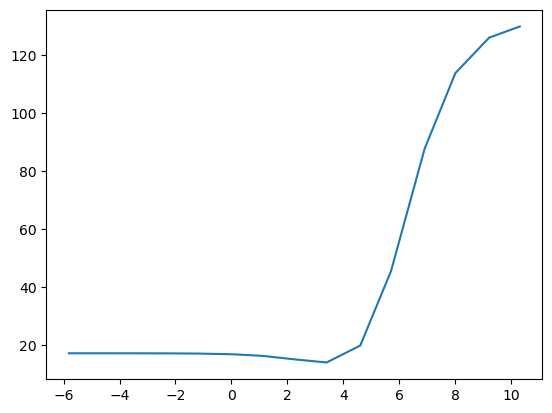

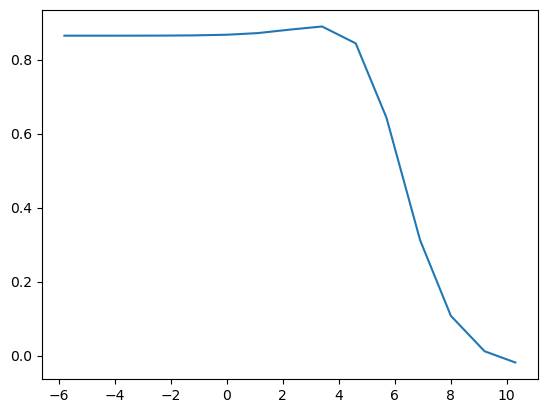

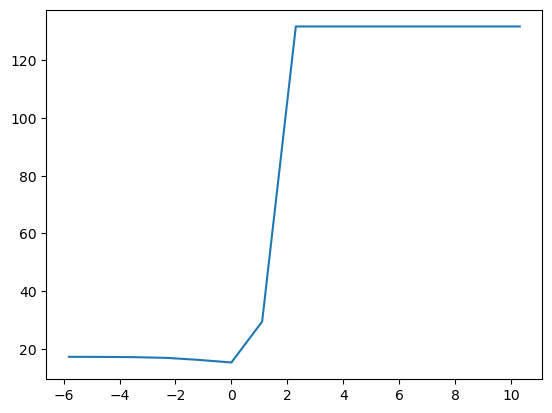

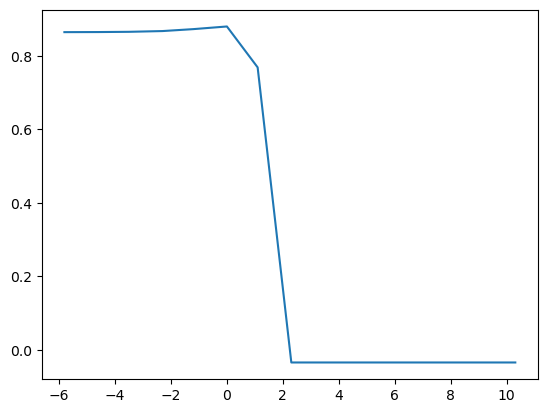

In [17]:
from sklearn import metrics
mse_ols=metrics.mean_squared_error(y_test,y_pred_ols)
r2_ols=metrics.r2_score(y_test,y_pred_ols)
print("mean squared error:",mse_ols,"\nr2 score:",r2_ols,"\ncoefficients (beta):",reg.coef_,"\n")

mse_ridge=[]
r2_ridge=[]
n=len(alphas)
for y_pred_row in y_pred_ridge[:n]:
    mse_ridge.append(metrics.mean_squared_error(y_test,y_pred_row))
    r2_ridge.append(metrics.r2_score(y_test,y_pred_row))
plt.figure()
plt.plot(log_al[:n],mse_ridge)
plt.figure()
plt.plot(log_al[:n],r2_ridge)

mse_lasso=[mse_ols]
r2_lasso=[r2_ols]
for y_pred_row in y_pred_lasso[:n-1]:
    mse_lasso.append(metrics.mean_squared_error(y_test,y_pred_row))
    r2_lasso.append(metrics.r2_score(y_test,y_pred_row))
plt.figure()
plt.plot(log_al[:n],mse_lasso)
plt.figure()
plt.plot(log_al[:n],r2_lasso)